In [5]:
import numpy as np

np.random.seed(42)

m = 200  # numero de ejemplos de entrenamiento
X = np.random.randn(2, m)  # shape: (n_features, m)

In [6]:
# Generamos etiquetas con una relacion lineal + ruido
y_true_logit = 0.8 * X[0] - 1.2 * X[1]
y = (y_true_logit + np.random.randn(m) * 0.5 > 0).astype(float)  # shape: (m,)

# Iniciamos parametros

n = X.shape[0]      # dimension de entrada: 2
w = np.zeros((n,))  # shape: (n,)
b = 0.0

alpha = 0.1   # tasa de aprendizaje
epochs = 500  # numero de iteraciones de gradiente descendente

# Funcion sigmoide
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

costos = []
report_epochs = {0, 250, epochs - 1}

for epoch in range(epochs):

    # FORWARD
    z = np.dot(w, X) + b          # shape: (m,)
    y_hat = sigmoid(z)             # shape: (m,)

    # Funcion de Loss (binary cross-entropy)
    eps = 1e-8
    J = -np.mean(y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps))
    costos.append(J)

    if epoch in report_epochs:
        label = "final" if epoch == epochs - 1 else str(epoch)
        print(f"Epoca {label:>5} | Costo J = {J:.6f}")

    # Backward
    dz = (y_hat - y)
    dw = np.dot(X, dz) / m
    db = np.mean(dz)

    # Update de parametros
    w = w - alpha * dw
    b = b - alpha * db

z_final = np.dot(w, X) + b
y_pred = (sigmoid(z_final) >= 0.5).astype(float)
accuracy = np.mean(y_pred == y)
print(f"\nExactitud final en entrenamiento: {accuracy*100:.1f}%")
print(f"Pesos aprendidos: w = {w}, b = {b:.4f}")

Epoca     0 | Costo J = 0.693147
Epoca   250 | Costo J = 0.275725
Epoca final | Costo J = 0.248261

Exactitud final en entrenamiento: 89.0%
Pesos aprendidos: w = [ 1.66477373 -3.1010956 ], b = -0.2668


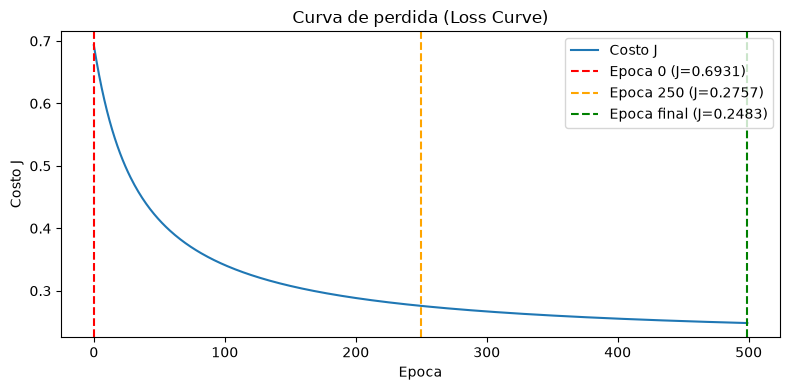

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(costos, label="Costo J")
plt.axvline(x=0,   color="red",   linestyle="--", label=f"Epoca 0 (J={costos[0]:.4f})")
plt.axvline(x=250, color="orange", linestyle="--", label=f"Epoca 250 (J={costos[250]:.4f})")
plt.axvline(x=499, color="green",  linestyle="--", label=f"Epoca final (J={costos[-1]:.4f})")
plt.xlabel("Epoca")
plt.ylabel("Costo J")
plt.title("Curva de perdida (Loss Curve)")
plt.legend()
plt.tight_layout()
plt.show()